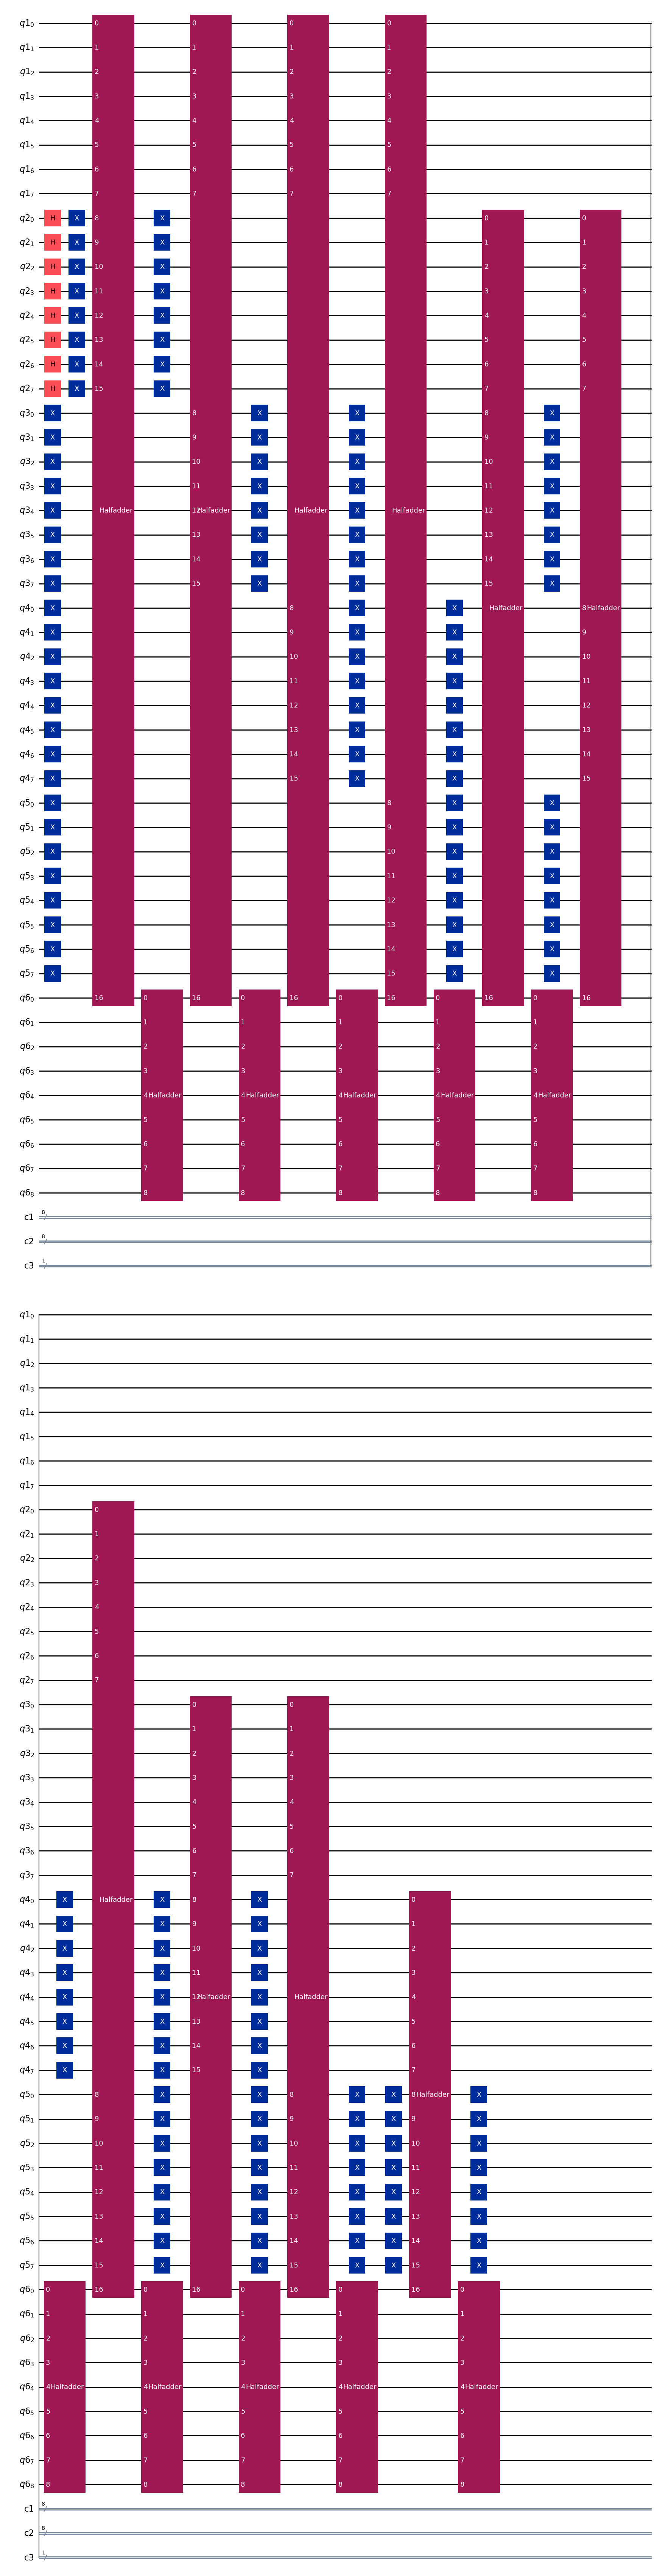

In [7]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import HalfAdderGate
from qiskit_aer import AerSimulator

def make_circuit (N_COUNT: int) -> QuantumCircuit:
    qr1 = QuantumRegister(N_COUNT, 'q1') # 0-7,
    qr2 = QuantumRegister(N_COUNT, 'q2') # 8-15,
    qr3 = QuantumRegister(N_COUNT, 'q3') # 16-23
    qr4 = QuantumRegister(N_COUNT, 'q4') # 24-31
    qr5 = QuantumRegister(N_COUNT, 'q5') # 32-39
    cl1 = ClassicalRegister(N_COUNT, 'c1')
    cl2 = ClassicalRegister(N_COUNT, 'c2')
    qr6 = QuantumRegister(N_COUNT+1, 'q6')
    cl3 = ClassicalRegister(1, 'c3')
    qc = QuantumCircuit(qr1, qr2, qr3, qr4, qr5, qr6, cl1, cl2, cl3)

    for q in range(N_COUNT,2*N_COUNT):
        qc.h(q)
    adder = HalfAdderGate(num_state_qubits=N_COUNT)
    oneAdder = HalfAdderGate(num_state_qubits=N_COUNT//2)
    qc.x(range(N_COUNT,2*N_COUNT))
    qc.append(adder, [*range(0,2*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(N_COUNT,2*N_COUNT))
    qc.x(range(2*N_COUNT,3*N_COUNT))
    qc.append(adder, [*range(0,N_COUNT),*range(2*N_COUNT,3*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(2*N_COUNT,3*N_COUNT))
    qc.x(range(3*N_COUNT,4*N_COUNT))
    qc.append(adder, [*range(0,N_COUNT),*range(3*N_COUNT,4*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(3*N_COUNT,4*N_COUNT))
    qc.x(range(4*N_COUNT, 5*N_COUNT))
    qc.append(adder, [*range(0,N_COUNT),*range(4*N_COUNT, 5*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(4*N_COUNT, 5*N_COUNT))
    qc.x(range(2*N_COUNT,3*N_COUNT))
    qc.append(adder, [*range(N_COUNT,2*N_COUNT),*range(2*N_COUNT,3*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(2*N_COUNT,3*N_COUNT))
    qc.x(range(3*N_COUNT,4*N_COUNT))
    qc.append(adder, [*range(N_COUNT,2*N_COUNT),*range(3*N_COUNT,4*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(3*N_COUNT,4*N_COUNT))
    qc.x(range(4*N_COUNT,5*N_COUNT))
    qc.append(adder, [*range(N_COUNT,2*N_COUNT),*range(4*N_COUNT,5*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(4*N_COUNT,5*N_COUNT))
    qc.x(range(3*N_COUNT,4*N_COUNT))
    qc.append(adder, [*range(2*N_COUNT,3*N_COUNT),*range(3*N_COUNT,4*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(3*N_COUNT,4*N_COUNT))
    qc.x(range(4*N_COUNT,5*N_COUNT))
    qc.append(adder, [*range(2*N_COUNT,3*N_COUNT),*range(4*N_COUNT,5*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(4*N_COUNT,5*N_COUNT))
    qc.x(range(4*N_COUNT,5*N_COUNT))
    qc.append(adder, [*range(3*N_COUNT,4*N_COUNT),*range(4*N_COUNT,5*N_COUNT), qr6[0]])
    qc.append(oneAdder, qr6)
    qc.x(range(4*N_COUNT,5*N_COUNT))
    return qc

qc = make_circuit(8)
qc.draw('mpl')

In [8]:
print('qc results')
print('gates used: ', dict(qc.count_ops()))
print('total # of gates used: ', sum(dict(qc.count_ops()).values()))
print('number of qubits: ', qc.num_qubits)

qc results
gates used:  {'x': 160, 'HalfAdder': 20, 'h': 8}
total # of gates used:  188
number of qubits:  49


In [9]:
# The circuit is too large to transpile
simulator = AerSimulator()
qcircuit = transpile(qc, simulator)

CircuitTooWideForTarget: 'Number of qubits (49) in circuit-52 is greater than maximum (30) in the coupling_map'

In [ ]:
result = simulator.run(qcircuit).result()

In [ ]:
print('untranspiled qc results')
print('gates used: ', dict(qc.count_ops()))
print('total # of gates used: ', sum(dict(qc.count_ops()).values()))
print('number of qubits: ', qc.num_qubits)
print ('transpiled qcircuit results')
print('gates used: ', dict(qcircuit.count_ops()))
print('total # of gates used: ', sum(dict(qcircuit.count_ops()).values()))
print('number of qubits: ', qcircuit.num_qubits)
counts = result.get_counts(qc)
plot_histogram(counts, title='Bell-State counts')